# Système de Recommandation — LSA + KNN

## Approche
1. **LSA** (Latent Semantic Analysis) : réduit la matrice utilisateur-produit en facteurs latents pour capturer les relations cachées entre utilisateurs et produits
2. **KNN** (K-Nearest Neighbors) : utilise ces facteurs latents pour trouver les utilisateurs similaires et générer des recommandations

## Étape 1 — Chargement des données

In [1]:
import pandas as pd
import numpy as np
import json

df_train = pd.read_csv("../data/processed/train.csv")
df_test  = pd.read_csv("../data/processed/test.csv")

with open("../data/processed/user2idx.json") as f:
    user2idx = json.load(f)
with open("../data/processed/item2idx.json") as f:
    item2idx = json.load(f)

# Dictionnaires inverses pour retrouver les IDs originaux
idx2user = {v: k for k, v in user2idx.items()}
idx2item = {v: k for k, v in item2idx.items()}

n_users = len(user2idx)
n_items = len(item2idx)

print(f"Train : {len(df_train):,} avis")
print(f"Test  : {len(df_test):,} avis")
print(f"Utilisateurs : {n_users:,} | Produits : {n_items:,}")

Train : 4,803 avis
Test  : 806 avis
Utilisateurs : 806 | Produits : 730


## Étape 2 — Construction de la matrice utilisateur-produit

On construit une matrice **creuse (sparse)** pour économiser la mémoire.
Chaque cellule contient la **note normalisée** de l'utilisateur pour ce produit (0 si pas de note).

In [2]:
from scipy.sparse import csr_matrix

rows = df_train['user_idx'].values
cols = df_train['item_idx'].values
vals = df_train['rating_normalized'].values

# Matrice sparse (users × produits)
matrice = csr_matrix((vals, (rows, cols)), shape=(n_users, n_items))

sparsite = (1 - matrice.nnz / (n_users * n_items)) * 100
print(f"Dimensions : {matrice.shape}")
print(f"Valeurs non-nulles : {matrice.nnz:,}")
print(f"Sparsité : {sparsite:.4f}%")

Dimensions : (806, 730)
Valeurs non-nulles : 4,803
Sparsité : 99.1837%


## Étape 3 — Application de LSA

`TruncatedSVD` de scikit-learn est l'implémentation standard de LSA.
Il décompose la matrice en **N_COMPONENTS facteurs latents** qui capturent les relations entre utilisateurs et produits.

On commence par trouver le bon 

  10 composantes → variance expliquée : 16.43%
  20 composantes → variance expliquée : 27.08%
  30 composantes → variance expliquée : 35.06%
  50 composantes → variance expliquée : 46.96%
  75 composantes → variance expliquée : 58.56%
 100 composantes → variance expliquée : 67.27%


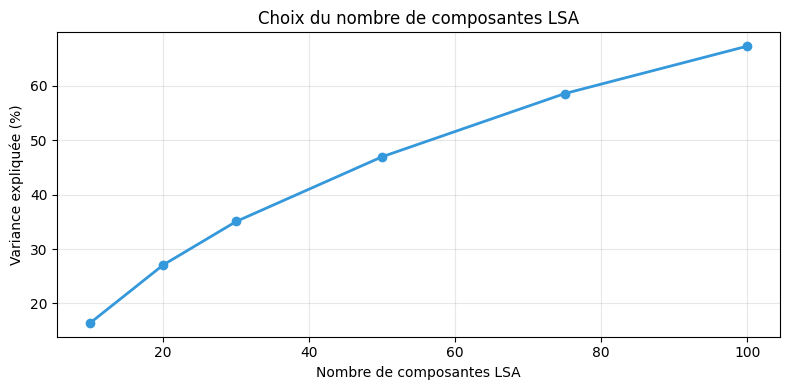

In [3]:
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD

# Test sur plusieurs valeurs de composantes
composantes_test = [10, 20, 30, 50, 75, 100]
variances = []

for n in composantes_test:
    svd = TruncatedSVD(n_components=n, random_state=42)
    svd.fit(matrice)
    variances.append(svd.explained_variance_ratio_.sum() * 100)
    print(f"{n:>4} composantes → variance expliquée : {variances[-1]:.2f}%")

# Visualisation
plt.figure(figsize=(8, 4))
plt.plot(composantes_test, variances, marker='o', color='#3498db', linewidth=2)
plt.xlabel("Nombre de composantes LSA")
plt.ylabel("Variance expliquée (%)")
plt.title("Choix du nombre de composantes LSA")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/lsa_variance.png", dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Entraînement final avec le nombre de composantes retenu
N_COMPONENTS = 50

lsa = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
matrice_lsa = lsa.fit_transform(matrice)  # shape : (n_users, N_COMPONENTS)

variance_totale = lsa.explained_variance_ratio_.sum() * 100
print(f"LSA entraîné avec {N_COMPONENTS} composantes")
print(f"Variance expliquée : {variance_totale:.2f}%")
print(f"Shape matrice réduite : {matrice_lsa.shape}")
print(f"\nInterprétation : chaque utilisateur est représenté par {N_COMPONENTS} valeurs")
print(f"au lieu de {n_items:,} produits → réduction de x{n_items//N_COMPONENTS}")

LSA entraîné avec 50 composantes
Variance expliquée : 46.96%
Shape matrice réduite : (806, 50)

Interprétation : chaque utilisateur est représenté par 50 valeurs
au lieu de 730 produits → réduction de x14


## Étape 4 — Modèle KNN sur les représentations LSA

On utilise la **similarité cosinus** : deux utilisateurs sont similaires si leur profil LSA pointe dans la même direction, indépendamment


In [5]:
from sklearn.neighbors import NearestNeighbors

K = 10  # nombre de voisins

knn = NearestNeighbors(n_neighbors=K + 1, metric='cosine', algorithm='brute')
knn.fit(matrice_lsa)

print(f"Modèle KNN entraîné")
print(f"  Voisins : {K}")
print(f"  Métrique : cosinus")
print(f"  Données : matrice LSA ({matrice_lsa.shape[0]:,} users × {matrice_lsa.shape[1]} composantes)")

Modèle KNN entraîné
  Voisins : 10
  Métrique : cosinus
  Données : matrice LSA (806 users × 50 composantes)


## Étape 5 — Génération de recommandations

Fonction de recommandation : pour un utilisateur donné, on trouve ses K voisins, on récupère leurs produits bien notés, et on filtre ceux que l'utilisateur a déjà vus.

In [7]:
def recommander(user_id, n_reco=5):
    """
    Retourne les n_reco produits recommandés pour un utilisateur.
    """
    if user_id not in user2idx:
        print(f"Utilisateur inconnu : {user_id}")
        return []

    user_idx = user2idx[user_id]

    # Trouver les K voisins les plus similaires
    distances, indices = knn.kneighbors([matrice_lsa[user_idx]])
    voisins_idx = indices[0][1:]  # exclure l'utilisateur lui-même

    # Produits déjà notés par l'utilisateur cible
    deja_vus = set(df_train[df_train['user_idx'] == user_idx]['item_idx'])

    # Agréger les notes des voisins sur les produits non vus
    scores = {}
    for voisin_idx in voisins_idx:
        avis_voisin = df_train[df_train['user_idx'] == voisin_idx]
        for _, row in avis_voisin.iterrows():
            item = int(row['item_idx'])
            if item not in deja_vus:
                scores[item] = scores.get(item, 0) + row['rating_normalized']

    # Trier par score décroissant
    top_items = sorted(scores, key=scores.get, reverse=True)[:n_reco]
    return [(idx2item[i], round(scores[i], 3)) for i in top_items]  # clé entière, pas str


# Test sur un utilisateur du jeu de test
user_exemple = df_test['user_id'].iloc[0]
recos = recommander(user_exemple, n_reco=5)

print(f"Recommandations pour l'utilisateur : {user_exemple}\n")
print(f"{'Rang':<5} {'Produit (ASIN)':<15} {'Score'}")
print("-" * 35)
for rang, (asin, score) in enumerate(recos, 1):
    print(f"{rang:<5} {asin:<15} {score}")

Recommandations pour l'utilisateur : AE23ZBUF2YVBQPH2NN6F5XSA3QYQ

Rang  Produit (ASIN)  Score
-----------------------------------
1     B087D7MVHB      2.878
2     B09H6XWD7C      0.778
3     B07D5FBFQ4      0.778
4     B08B5FJMHM      0.778
5     B089CSF11Y      0.778


## Étape 6 — Évaluation du modèle

On évalue avec deux métriques standard :
- **Précision@K** : parmi les K produits recommandés, combien sont dans le test ?
- **RMSE** : erreur quadratique moyenne entre la note prédite et la note réelle

In [8]:
N_RECO = 5
hits = 0
total = 0

for _, row_test in df_test.iterrows():
    user_id = row_test['user_id']
    item_reel = row_test['asin']

    recos = recommander(user_id, n_reco=N_RECO)
    asins_recommandes = [asin for asin, _ in recos]

    if item_reel in asins_recommandes:
        hits += 1
    total += 1

precision = hits / total * 100
print(f"=== Évaluation LSA + KNN ===")
print(f"Utilisateurs évalués : {total}")
print(f"Hits (produit réel recommandé) : {hits}")
print(f"Précision@{N_RECO} : {precision:.2f}%")

=== Évaluation LSA + KNN ===
Utilisateurs évalués : 806
Hits (produit réel recommandé) : 10
Précision@5 : 1.24%


## Étape 7 — Sauvegarde du modèle

In [9]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

# Sauvegarde des composants du modèle
joblib.dump(lsa,         "../models/lsa_model.joblib")
joblib.dump(knn,         "../models/knn_model.joblib")
joblib.dump(matrice_lsa, "../models/matrice_lsa.joblib")

# Sauvegarde de la matrice sparse d'origine
from scipy.sparse import save_npz
save_npz("../models/matrice_sparse.npz", matrice)

print("Modèles sauvegardés :")
print("  ../models/lsa_model.joblib    — modèle LSA (TruncatedSVD)")
print("  ../models/knn_model.joblib    — modèle KNN (NearestNeighbors)")
print("  ../models/matrice_lsa.joblib  — vecteurs utilisateurs réduits (806 × 50)")
print("  ../models/matrice_sparse.npz  — matrice utilisateur-produit sparse")

Modèles sauvegardés :
  ../models/lsa_model.joblib    — modèle LSA (TruncatedSVD)
  ../models/knn_model.joblib    — modèle KNN (NearestNeighbors)
  ../models/matrice_lsa.joblib  — vecteurs utilisateurs réduits (806 × 50)
  ../models/matrice_sparse.npz  — matrice utilisateur-produit sparse


In [10]:
import joblib

lsa         = joblib.load("../models/lsa_model.joblib")
knn         = joblib.load("../models/knn_model.joblib")
matrice_lsa = joblib.load("../models/matrice_lsa.joblib")

print(lsa)
print(knn)
print(matrice_lsa.shape)

TruncatedSVD(n_components=50, random_state=42)
NearestNeighbors(algorithm='brute', metric='cosine', n_neighbors=11)
(806, 50)


In [11]:
from scipy.sparse import load_npz

matrice = load_npz("../models/matrice_sparse.npz")
print(matrice.shape)

(806, 730)
